In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('PHQ-9_Dataset_5th Edition.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*80)


Dataset Shape: (682, 16)



CLASS IMBALANCE ANALYSIS: Gender × Severity Intersection

Cross-tabulation: Severity × Gender
Gender             Female  Male  All
PHQ_Severity                        
Minimal                64   142  206
Mild                   72    83  155
Moderate               56    72  128
Moderately severe      44    81  125
Severe                 28    40   68
All                   264   418  682

Percentage Distribution:
Gender                Female       Male
PHQ_Severity                           
Minimal             9.384164  20.821114
Mild               10.557185  12.170088
Moderate            8.211144  10.557185
Moderately severe   6.451613  11.876833
Severe              4.105572   5.865103

🚨 PROBLEM IDENTIFIED:
Minimal + Female: 64 samples (9.4% of entire dataset)
This single combination dominates the dataset!


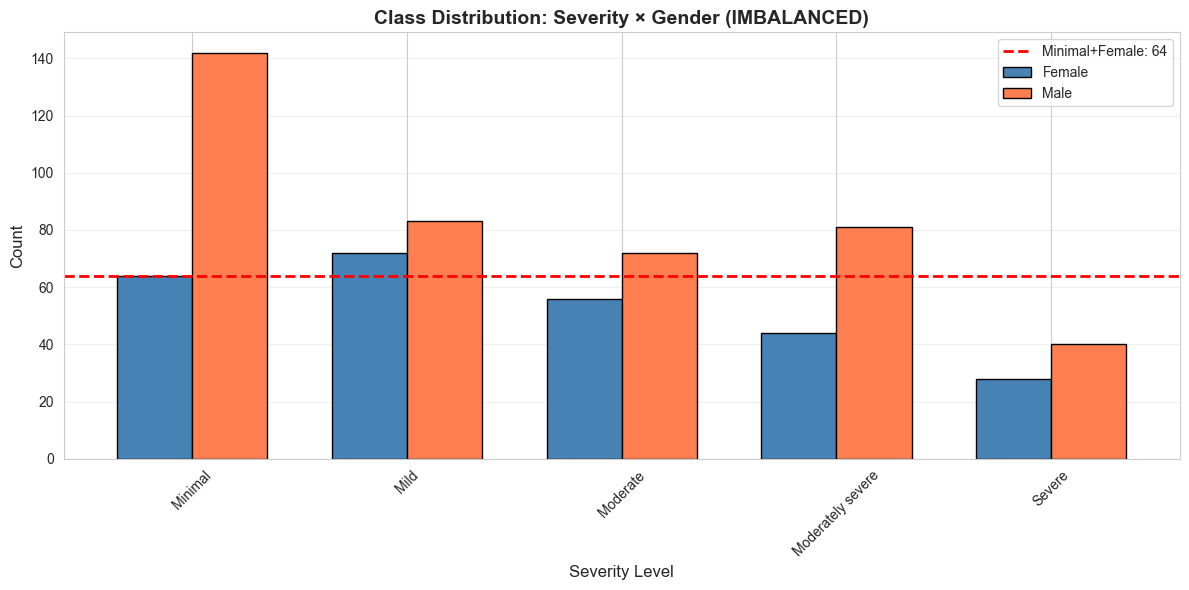

In [4]:
# Analyze class distribution by gender
print("=" * 80)
print("CLASS IMBALANCE ANALYSIS: Gender × Severity Intersection")
print("=" * 80)

# Create cross-tabulation
cross_tab = pd.crosstab(df['PHQ_Severity'], df['Gender'], margins=True)
cross_tab = cross_tab.reindex(['Minimal', 'Mild', 'Moderate', 'Moderately severe', 'Severe', 'All'])
print("\nCross-tabulation: Severity × Gender")
print(cross_tab)

# Calculate percentages
cross_tab_pct = pd.crosstab(df['PHQ_Severity'], df['Gender'], normalize='all') * 100
cross_tab_pct = cross_tab_pct.reindex(['Minimal', 'Mild', 'Moderate', 'Moderately severe', 'Severe'])
print("\nPercentage Distribution:")
print(cross_tab_pct)

# Identify the problem
print("\n" + "=" * 80)
print("🚨 PROBLEM IDENTIFIED:")
minimal_female = len(df[(df['PHQ_Severity'] == 'Minimal') & (df['Gender'] == 'Female')])
total = len(df)
print(f"Minimal + Female: {minimal_female} samples ({minimal_female/total*100:.1f}% of entire dataset)")
print(f"This single combination dominates the dataset!")
print("=" * 80)

# Visualize the problem
fig, ax = plt.subplots(figsize=(12, 6))
cross_tab_plot = pd.crosstab(df['PHQ_Severity'], df['Gender'])
cross_tab_plot = cross_tab_plot.reindex(['Minimal', 'Mild', 'Moderate', 'Moderately severe', 'Severe'])
cross_tab_plot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black', width=0.7)
ax.set_title('Class Distribution: Severity × Gender (IMBALANCED)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Severity Level', fontsize=12)
ax.legend(title='Gender', labels=['Female', 'Male'])
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Highlight the problem area
minimal_female_bar = cross_tab_plot.loc['Minimal', 'Female']
ax.axhline(y=minimal_female_bar, color='red', linestyle='--', linewidth=2, label=f'Minimal+Female: {minimal_female}')
ax.legend()

plt.tight_layout()
plt.show()

In [5]:
# Anomaly checks
print("=" * 80)
print("ANOMALY CHECKS")
print("=" * 80)

# 1) Missing values and duplicates
missing_counts = df.isnull().sum()
print("\nMissing values (non-zero only):")
print(missing_counts[missing_counts > 0])

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count}")

# 2) Range checks for numeric fields
age_outliers = df[(df['Age'] < 15) | (df['Age'] > 30)]
phq_total_outliers = df[(df['PHQ_Total'] < 0) | (df['PHQ_Total'] > 27)]
print(f"\nAge outliers (<15 or >30): {len(age_outliers)}")
print(f"PHQ_Total outliers (<0 or >27): {len(phq_total_outliers)}")

# 3) Category validation
expected_gender = {'Male', 'Female'}
expected_severity = {'Minimal', 'Mild', 'Moderate', 'Moderately severe', 'Severe'}

invalid_gender = df[~df['Gender'].isin(expected_gender)]
invalid_severity = df[~df['PHQ_Severity'].isin(expected_severity)]
print(f"\nInvalid Gender values: {len(invalid_gender)}")
print(f"Invalid PHQ_Severity values: {len(invalid_severity)}")

# 4) Symptom response validation
expected_symptom_values = {'Not at all', 'Several days', 'More than half the days', 'Nearly every day'}
meta_cols = {'Age', 'Gender', 'PHQ_Total', 'PHQ_Severity', 'Sleep Quality', 'Study Pressure', 'Financial Pressure'}
symptom_cols = [c for c in df.columns if c not in meta_cols]

symptom_valid_mask = df[symptom_cols].apply(lambda col: col.isin(expected_symptom_values))
invalid_symptom_rows = df[~symptom_valid_mask.all(axis=1)]
print(f"\nRows with invalid symptom responses: {len(invalid_symptom_rows)}")

# 5) Consistency check: recompute PHQ_Total from symptom responses
score_map = {
    'Not at all': 0,
    'Several days': 1,
    'More than half the days': 2,
    'Nearly every day': 3
}

symptom_scores = df[symptom_cols].replace(score_map)
recomputed_total = symptom_scores.sum(axis=1)
phq_total_mismatch = df[recomputed_total != df['PHQ_Total']]

print(f"\nPHQ_Total mismatches (recomputed vs given): {len(phq_total_mismatch)}")
if len(phq_total_mismatch) > 0:
    print("Sample mismatches:")
    display(phq_total_mismatch.head())


ANOMALY CHECKS

Missing values (non-zero only):
Series([], dtype: int64)

Duplicate rows: 3

Age outliers (<15 or >30): 0
PHQ_Total outliers (<0 or >27): 0

Invalid Gender values: 0
Invalid PHQ_Severity values: 0

Rows with invalid symptom responses: 0

PHQ_Total mismatches (recomputed vs given): 0


In [6]:
# Remove duplicate rows (keep first)
print("=" * 80)
print("REMOVE DUPLICATES")
print("=" * 80)

before_rows = len(df)
df = df.drop_duplicates(keep='first')
after_rows = len(df)
removed = before_rows - after_rows

print(f"Rows before: {before_rows}")
print(f"Rows after:  {after_rows}")
print(f"Duplicates removed: {removed}")

# Re-check duplicates
print(f"Remaining duplicates: {df.duplicated().sum()}")


REMOVE DUPLICATES
Rows before: 682
Rows after:  679
Duplicates removed: 3
Remaining duplicates: 0


CLASS DISTRIBUTION CHECKS

PHQ_Severity distribution:
PHQ_Severity
Minimal              203
Mild                 155
Moderate             128
Moderately severe    125
Severe                68
Name: count, dtype: int64

PHQ_Severity × Gender distribution:
Gender             Female  Male
PHQ_Severity                   
Minimal                64   139
Mild                   72    83
Moderate               56    72
Moderately severe      44    81
Severe                 28    40


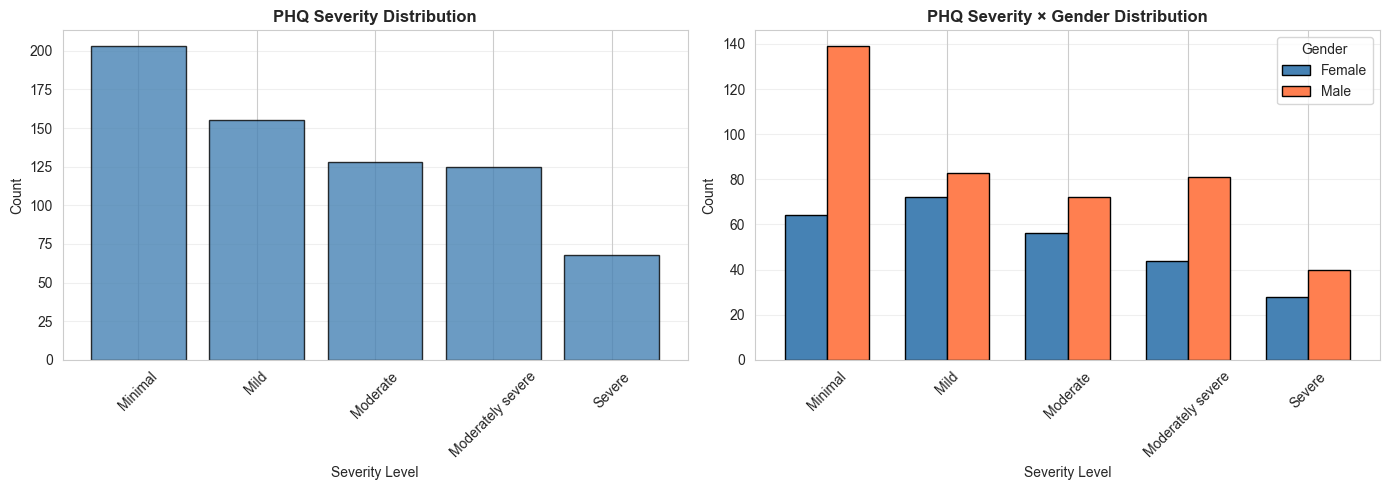

In [7]:
# Class distribution checks (after duplicate removal)
print("=" * 80)
print("CLASS DISTRIBUTION CHECKS")
print("=" * 80)

# PHQ Severity distribution
severity_order = ['Minimal', 'Mild', 'Moderate', 'Moderately severe', 'Severe']
severity_counts = df['PHQ_Severity'].value_counts().reindex(severity_order)
print("\nPHQ_Severity distribution:")
print(severity_counts)

# PHQ Severity × Gender distribution
severity_gender = pd.crosstab(df['PHQ_Severity'], df['Gender']).reindex(severity_order)
print("\nPHQ_Severity × Gender distribution:")
print(severity_gender)

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combined severity distribution
axes[0].bar(severity_counts.index, severity_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('PHQ Severity Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Severity by gender distribution
severity_gender.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black', width=0.7)
axes[1].set_title('PHQ Severity × Gender Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Gender')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [8]:
# Display all rows where Gender is male and PHQ_Severity is 'Minimal'
male_minimal = df[(df['Gender'] == 'Male') & (df['PHQ_Severity'] == 'Minimal')]
print(f"Number of Male-Minimal rows: {male_minimal.shape[0]}")
display(male_minimal.head(20))  # Show first 20 rows for inspection

Number of Male-Minimal rows: 139


,Age,Gender,Little interest or pleasure in doing things,"Feeling down, depressed, or hopeless","Trouble falling or staying asleep, or sleeping too much",Feeling tired or having little energy,Poor appetite or overeating,Feeling bad about yourself—or that you are a failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual,Thoughts that you would be better off dead or of hurting yourself in some way,PHQ_Total,PHQ_Severity,Sleep Quality,Study Pressure,Financial Pressure
0,22,Male,More than half the days,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,More than half the days,Not at all,4,Minimal,Good,Good,Average
4,24,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,More than half the days,Not at all,2,Minimal,Good,Average,Good
5,19,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,0,Minimal,Good,Good,Good
11,19,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Several days,Not at all,Not at all,1,Minimal,Bad,Good,Bad
16,25,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Several days,1,Minimal,Good,Good,Good
17,20,Male,Not at all,Not at all,Not at all,More than half the days,Not at all,Not at all,Not at all,Several days,Not at all,3,Minimal,Good,Good,Good
19,26,Male,Not at all,Several days,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,1,Minimal,Good,Good,Good
23,18,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Several days,Several days,More than half the days,Not at all,4,Minimal,Good,Worst,Good
24,19,Male,Several days,Not at all,Not at all,Not at all,Several days,Not at all,Several days,Not at all,Several days,4,Minimal,Good,Good,Worst
25,26,Male,Not at all,Not at all,Not at all,Not at all,Not at all,Not at all,Several days,Not at all,Not at all,1,Minimal,Average,Average,Average


In [9]:
# STEP 1: Analyze Male × Minimal - Symptom Response Patterns
# ============================================================

# Filter Male + Minimal rows
male_minimal = df[(df['Gender'] == 'Male') & (df['PHQ_Severity'] == 'Minimal')].copy()
print(f"Male × Minimal: {len(male_minimal)} samples ({len(male_minimal)/len(df)*100:.1f}% of dataset)")

# Define symptom columns
symptom_cols = [col for col in df.columns if col not in 
                ['Age', 'Gender', 'PHQ_Total', 'PHQ_Severity', 'Sleep Quality', 'Study Pressure', 'Financial Pressure']]

print(f"\n9 PHQ-9 Symptom Questions:")
for i, col in enumerate(symptom_cols, 1):
    print(f"  Q{i}: {col[:50]}...")

# Show response distribution for each symptom
print("\n" + "="*60)
print("SYMPTOM RESPONSE DISTRIBUTION IN MALE × MINIMAL:")
print("="*60)
for col in symptom_cols:
    print(f"\n{col[:50]}...")
    print(male_minimal[col].value_counts())

Male × Minimal: 139 samples (20.5% of dataset)

9 PHQ-9 Symptom Questions:
  Q1: Little interest or pleasure in doing things ...
  Q2:   Feeling down, depressed, or hopeless  ...
  Q3:   Trouble falling or staying asleep, or sleeping t...
  Q4:   Feeling tired or having little energy  ...
  Q5:   Poor appetite or overeating  ...
  Q6: Feeling bad about yourself—or that you are a failu...
  Q7: Trouble concentrating on things, such as reading t...
  Q8: Moving or speaking so slowly that other people cou...
  Q9: Thoughts that you would be better off dead or of h...

SYMPTOM RESPONSE DISTRIBUTION IN MALE × MINIMAL:

Little interest or pleasure in doing things ...
Little interest or pleasure in doing things 
Not at all                 115
Several days                21
More than half the days      3
Name: count, dtype: int64

  Feeling down, depressed, or hopeless  ...
  Feeling down, depressed, or hopeless  
Not at all                 106
Several days                29
More than half the

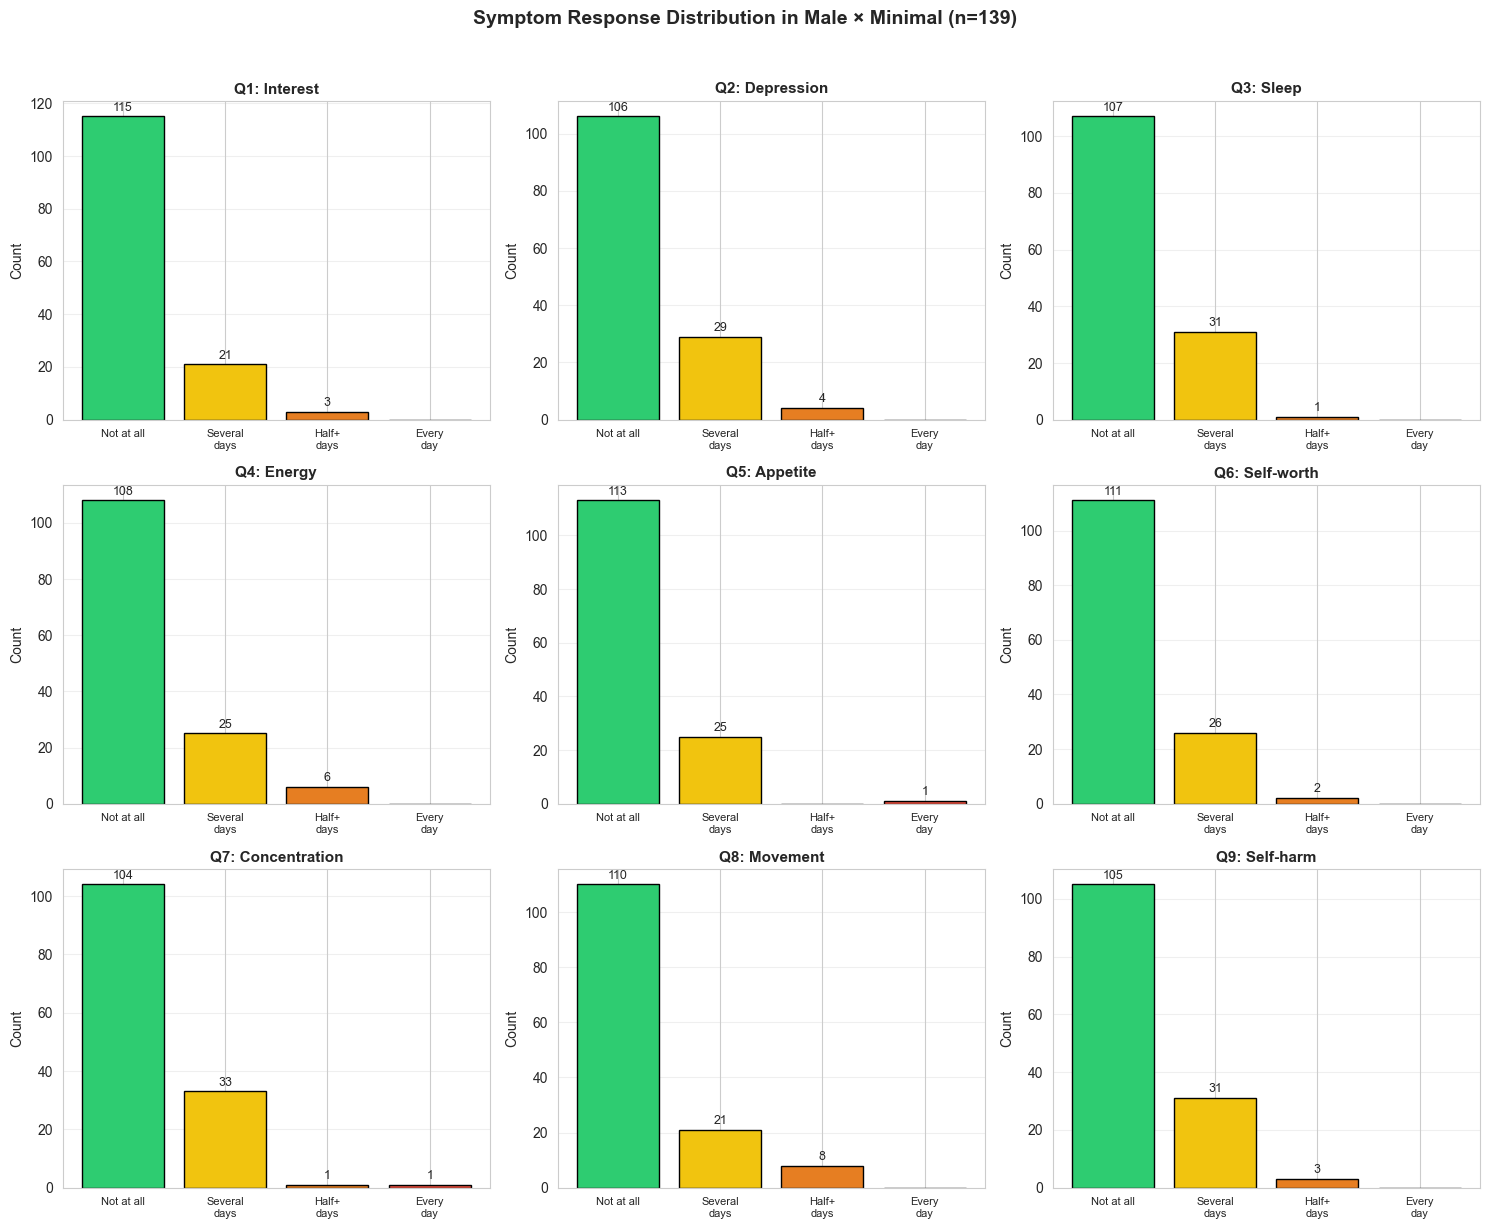


📊 Key Observation: Most Male × Minimal responses are 'Not at all' (green bars)
   This is expected since Minimal = PHQ score 0-4


In [10]:
# STEP 1: Visualize Male × Minimal - Symptom Response Patterns
# =============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Filter Male + Minimal rows
male_minimal = df[(df['Gender'] == 'Male') & (df['PHQ_Severity'] == 'Minimal')].copy()

# Define symptom columns (the 9 PHQ-9 questions)
symptom_cols = [col for col in df.columns if col not in 
                ['Age', 'Gender', 'PHQ_Total', 'PHQ_Severity', 'Sleep Quality', 'Study Pressure', 'Financial Pressure']]

# Short labels for visualization
short_labels = ['Q1: Interest', 'Q2: Depression', 'Q3: Sleep', 'Q4: Energy', 
                'Q5: Appetite', 'Q6: Self-worth', 'Q7: Concentration', 'Q8: Movement', 'Q9: Self-harm']

# Score mapping
score_map = {'Not at all': 0, 'Several days': 1, 'More than half the days': 2, 'Nearly every day': 3}

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']  # Green to Red

for i, (col, label) in enumerate(zip(symptom_cols, short_labels)):
    counts = male_minimal[col].value_counts().reindex(['Not at all', 'Several days', 'More than half the days', 'Nearly every day']).fillna(0)
    bars = axes[i].bar(range(4), counts.values, color=colors, edgecolor='black')
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xticks(range(4))
    axes[i].set_xticklabels(['Not at all', 'Several\ndays', 'Half+\ndays', 'Every\nday'], fontsize=8)
    axes[i].set_ylabel('Count')
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for bar, val in zip(bars, counts.values):
        if val > 0:
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, int(val), 
                        ha='center', va='bottom', fontsize=9)

plt.suptitle('Symptom Response Distribution in Male × Minimal (n=139)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Key Observation: Most Male × Minimal responses are 'Not at all' (green bars)")
print(f"   This is expected since Minimal = PHQ score 0-4")

In [11]:
# Check all columns in the dataset
# =================================

print("📋 ALL COLUMNS IN DATASET:")
print("=" * 60)

for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

print("\n" + "=" * 60)
print(f"Total: {len(df.columns)} columns")

# Also show data types
print("\n📊 COLUMN DATA TYPES:")
print(df.dtypes)

📋 ALL COLUMNS IN DATASET:
 1. Age
 2. Gender
 3. Little interest or pleasure in doing things 
 4.   Feeling down, depressed, or hopeless  
 5.   Trouble falling or staying asleep, or sleeping too much  
 6.   Feeling tired or having little energy  
 7.   Poor appetite or overeating  
 8. Feeling bad about yourself—or that you are a failure or have let yourself or your family down  
 9. Trouble concentrating on things, such as reading the newspaper or watching television  
10. Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual  
11. Thoughts that you would be better off dead or of hurting yourself in some way  
12. PHQ_Total
13. PHQ_Severity
14. Sleep Quality
15. Study Pressure
16. Financial Pressure

Total: 16 columns

📊 COLUMN DATA TYPES:
Age                                                                                                                                   

ValueError: num must be an integer with 1 <= num <= 12, not 13

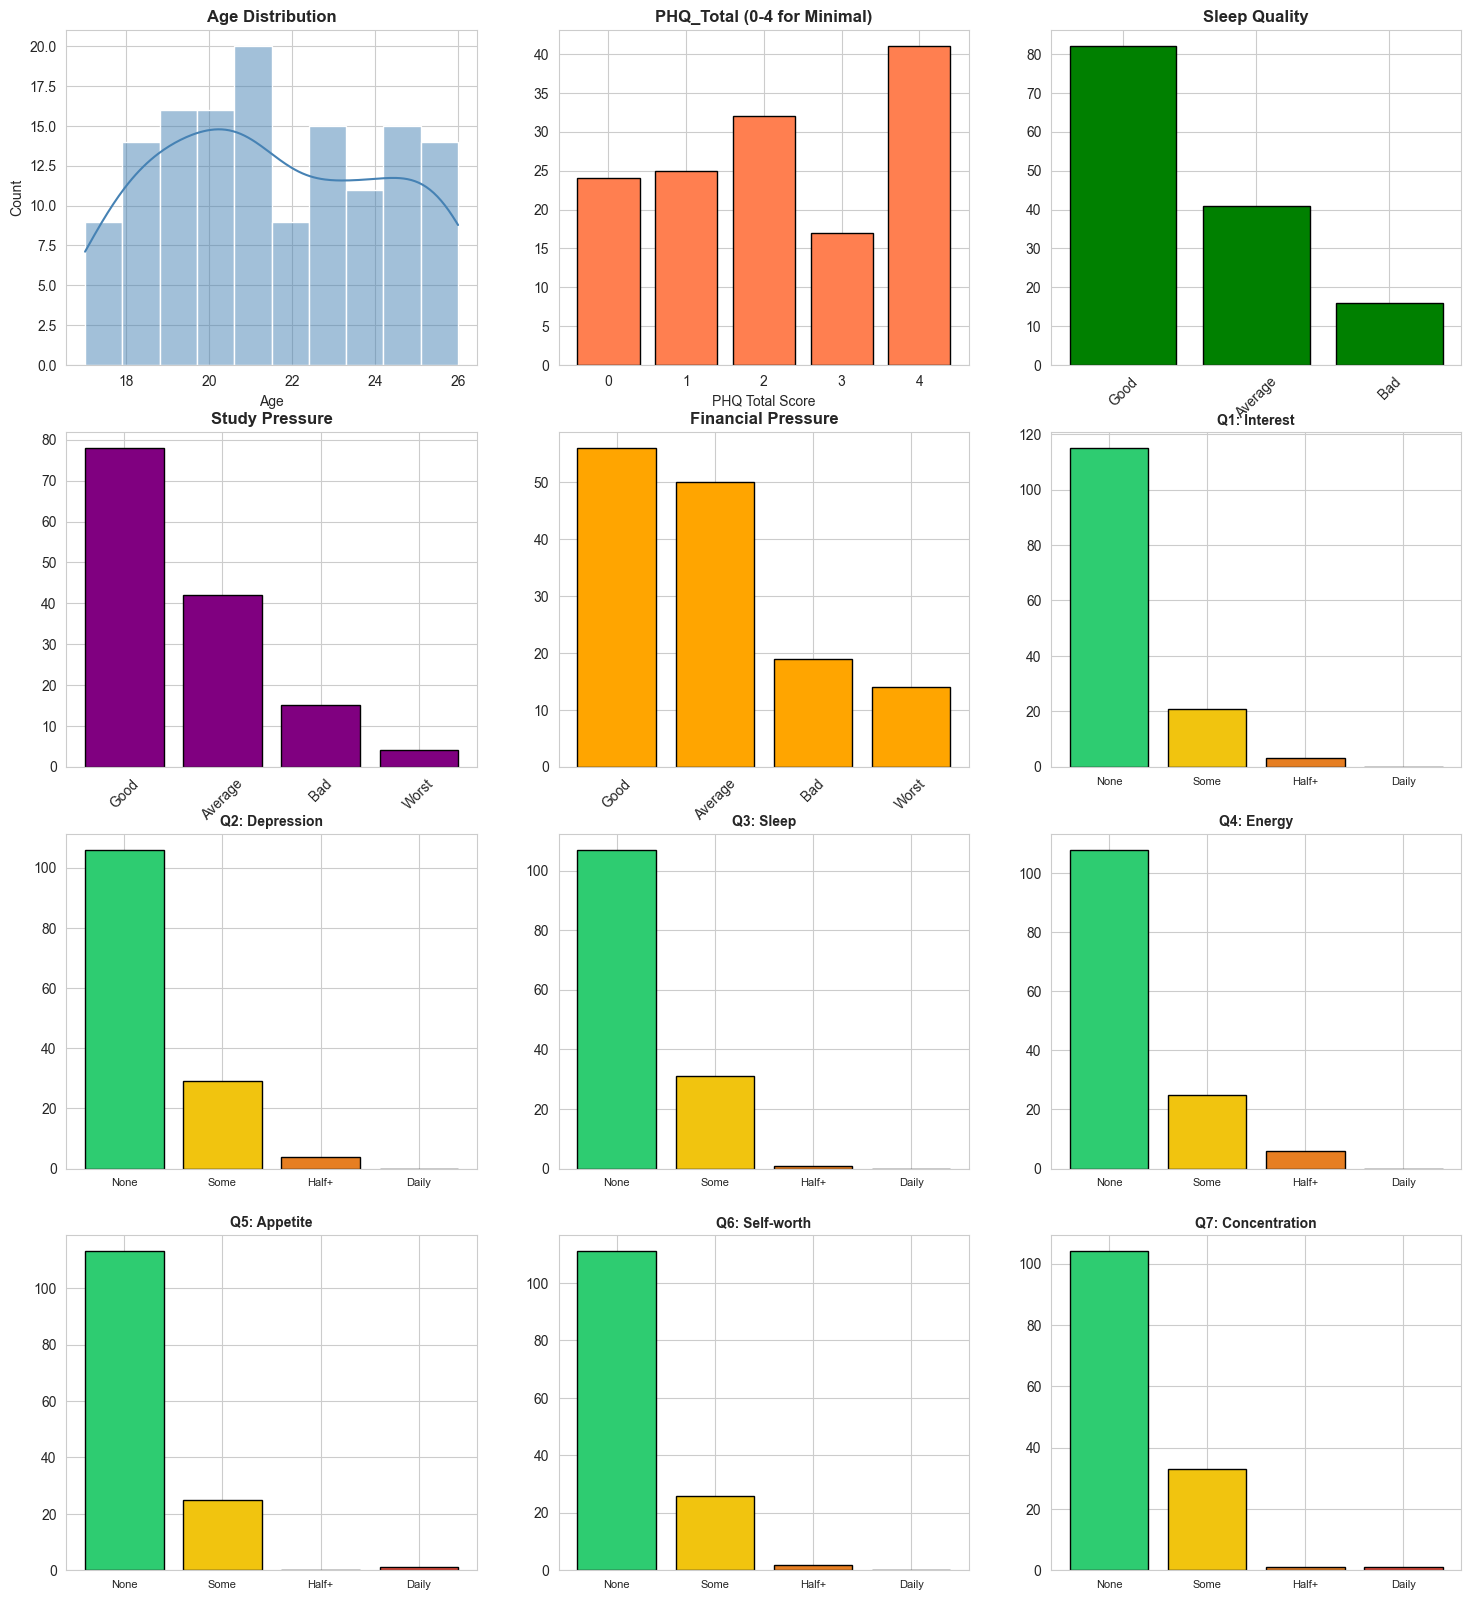

In [12]:
# VISUALIZE ALL COLUMNS - Male × Minimal Data
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Filter Male + Minimal
male_minimal = df[(df['Gender'] == 'Male') & (df['PHQ_Severity'] == 'Minimal')].copy()

# Create figure with subplots for each column
fig = plt.figure(figsize=(18, 20))

# 1. AGE Distribution
ax1 = fig.add_subplot(4, 3, 1)
sns.histplot(male_minimal['Age'], bins=10, kde=True, color='steelblue', ax=ax1)
ax1.set_title('Age Distribution', fontweight='bold')
ax1.set_xlabel('Age')

# 2. PHQ_Total Distribution
ax2 = fig.add_subplot(4, 3, 2)
phq_counts = male_minimal['PHQ_Total'].value_counts().sort_index()
ax2.bar(phq_counts.index, phq_counts.values, color='coral', edgecolor='black')
ax2.set_title('PHQ_Total (0-4 for Minimal)', fontweight='bold')
ax2.set_xlabel('PHQ Total Score')

# 3. Sleep Quality
ax3 = fig.add_subplot(4, 3, 3)
sleep_counts = male_minimal['Sleep Quality'].value_counts()
ax3.bar(sleep_counts.index, sleep_counts.values, color='green', edgecolor='black')
ax3.set_title('Sleep Quality', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# 4. Study Pressure
ax4 = fig.add_subplot(4, 3, 4)
study_counts = male_minimal['Study Pressure'].value_counts()
ax4.bar(study_counts.index, study_counts.values, color='purple', edgecolor='black')
ax4.set_title('Study Pressure', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# 5. Financial Pressure
ax5 = fig.add_subplot(4, 3, 5)
fin_counts = male_minimal['Financial Pressure'].value_counts()
ax5.bar(fin_counts.index, fin_counts.values, color='orange', edgecolor='black')
ax5.set_title('Financial Pressure', fontweight='bold')
ax5.tick_params(axis='x', rotation=45)

# 6-14. All 9 PHQ-9 Symptom Questions
symptom_cols = [col for col in df.columns if col not in 
                ['Age', 'Gender', 'PHQ_Total', 'PHQ_Severity', 'Sleep Quality', 'Study Pressure', 'Financial Pressure']]

short_labels = ['Q1: Interest', 'Q2: Depression', 'Q3: Sleep', 'Q4: Energy', 
                'Q5: Appetite', 'Q6: Self-worth', 'Q7: Concentration', 'Q8: Movement', 'Q9: Self-harm']

response_order = ['Not at all', 'Several days', 'More than half the days', 'Nearly every day']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

for i, (col, label) in enumerate(zip(symptom_cols, short_labels)):
    ax = fig.add_subplot(4, 3, i + 6)
    counts = male_minimal[col].value_counts().reindex(response_order).fillna(0)
    ax.bar(range(4), counts.values, color=colors, edgecolor='black')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['None', 'Some', 'Half+', 'Daily'], fontsize=8)

plt.suptitle('📊 ALL COLUMNS - Male × Minimal (n=139)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📋 SUMMARY:")
print(f"   Age: {male_minimal['Age'].min()}-{male_minimal['Age'].max()} years (mean: {male_minimal['Age'].mean():.1f})")
print(f"   PHQ_Total: {male_minimal['PHQ_Total'].min()}-{male_minimal['PHQ_Total'].max()} (mean: {male_minimal['PHQ_Total'].mean():.1f})")
print(f"   Most common Sleep Quality: {male_minimal['Sleep Quality'].mode()[0]}")
print(f"   Most common Study Pressure: {male_minimal['Study Pressure'].mode()[0]}")